In [2]:
import matplotlib.pyplot as plt
import numpy as np
import random
from eqnet_independent_copy import EqNet, GaussianDiffusion, DiffuserTrainer, DiffuserPlanner, CompositeReward, expand_spline_from_skip_list, StartReachingReward, GoalReachingReward, SkipTotalTimeSkipPenalty, CurvaturePenalty
from point_maze_skip import MinariTrajectoryDatasetWithPseudoActions
import torch
from matplotlib.patches import Rectangle
import mujoco

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

USE_POSITIONAL_ENCODING = False

print("\n" + "=" * 80)
print("EQ-NET CONFIGURATION")
print("=" * 80)
print(f"Positional Encoding: {USE_POSITIONAL_ENCODING}")
print("Architecture: Local convolutions (no downsampling) for shift equivariance")
print("Using MinariTrajectoryDatasetWithPseudoActions (pos + skip as action)")

    # ========================================================================
    # DATA
    # ========================================================================

# Use pseudo-action dataset
dataset = MinariTrajectoryDatasetWithPseudoActions(
    "D4RL/pointmaze/umaze-v2", horizon=32, n_chunks_frac= 0.5
)
print(f"\nDataset size: {len(dataset)} trajectory windows")
print(f"Trajectory dim (pos+skip): {dataset.traj_dim}")


Using device: cuda

EQ-NET CONFIGURATION
Positional Encoding: False
Architecture: Local convolutions (no downsampling) for shift equivariance
Using MinariTrajectoryDatasetWithPseudoActions (pos + skip as action)

Dataset size: 171693 trajectory windows
Trajectory dim (pos+skip): 3


In [14]:
# ========================================================================
    # MODEL
    # ========================================================================

eqnet = EqNet(
        state_dim=dataset.traj_dim,
        hidden_dim=128,
        time_dim=32,
        n_layers=10,  # Deep but local
    )

diffusion = GaussianDiffusion(timesteps=200)

print(f"\nModel parameters: {sum(p.numel() for p in eqnet.parameters()):,}")



Model parameters: 1,506,179


In [74]:
# ========================================================================
# TRAINING
# ========================================================================

trainer = DiffuserTrainer(
        model = eqnet,
        diffusion = diffusion,
        dataset=dataset,
        device = device,
    )

TRAIN_NEW = False
if TRAIN_NEW:
    print("\n" + "=" * 80)
    print("TRAINING")
    print("=" * 80)
    trainer.train(epochs=100, save_every=1)
else:
    print("\nLoading pre-trained model...")
    try:
        trainer.load("/scratch/network/ts4953/dataset_gen/rpmml-project/timeskip-diffuser/src/timeskip_diffuser/diffuser/checkpoints/diffuser_flat_eqnet_independent_epoch_28.pt")
        print("Loaded checkpoint successfully")
    except:
        print("No checkpoint found, using random initialization")

trainer.use_ema_for_inference()


Loading pre-trained model...
Loaded checkpoint successfully
Switched to EMA parameters for inference


In [127]:
# ========================================================================
# PLANNING
# ========================================================================

planner = DiffuserPlanner(eqnet, diffusion, dataset, device=device)

current = np.array([-1, -1, 0.88507522, 4.78210334])
goal = np.array([-1, 1.02245092])

reward_fn = CompositeReward(
    [
        StartReachingReward(current[:2], reward_scale=5.0),
        GoalReachingReward(goal, reward_scale=5.0),
        SkipTotalTimeSkipPenalty(reward_scale=0.0),
        CurvaturePenalty(reward_scale=0.1),
    ]
)

print("\n" + "=" * 80)
print("PLANNING WITH EQ-NET (pos + skip)")
print("=" * 80)

# Experiment 1: standard planning
print("\n--- Experiment 1: Standard Planning ---")
traj = planner.plan_and_reconstruct(
    current,
    goal,
    reward_fn=reward_fn,
    horizon=32,
    guidance_scale=1.0,
    condition_on_start=True,
    condition_on_goal=True,
    conditioning_schedule="constant",
    conditioning_strength=0.9,
    spline_func=expand_spline_from_skip_list,
)
coarse, = traj["coarse"],
coarse_pos= traj["coarse_pos"] 
coarse_skip=traj["coarse_skip"]              # (H,)
skip = traj["skip_list"]     # [(pos_i, skip_i)]
pos_dense=traj["pos_dense"]           # (N,2)
vel_dense=traj["vel_dense"]           # (N,2)
acc_dense=traj["acc_dense"]           # (N,2)  
print(f"Start (actual): {pos_dense[0]}")
print(f"Start (target): {current[:2]}")
print(f"Start error: {np.linalg.norm(pos_dense[0] - current[:2]):.4f}")
print(f"End: {pos_dense[-1]}")
print(f"Goal: {goal}")
print(f"Goal error: {np.linalg.norm(pos_dense[-1] - goal):.4f}")
print("\n" + "=" * 80)
print("EXPERIMENTS COMPLETE")
print("=" * 80)
print(pos_dense)


PLANNING WITH EQ-NET (pos + skip)

--- Experiment 1: Standard Planning ---
Start (actual): [-0.9990735  -0.99927926]
Start (target): [-1. -1.]
Start error: 0.0012
End: [-1.00376946  0.96245268]
Goal: [-1.          1.02245092]
Goal error: 0.0601

EXPERIMENTS COMPLETE
[[-0.9990735  -0.99927926]
 [-0.97260012 -0.99988171]
 [-0.91299351 -1.0010948 ]
 [-0.84997396 -1.00202714]
 [-0.78001176 -1.00295232]
 [-0.7063355  -1.00332368]
 [-0.63063868 -1.00279302]
 [-0.55636494 -1.00245435]
 [-0.48730313 -1.00223081]
 [-0.41820543 -1.00235728]
 [-0.34602324 -1.00280525]
 [-0.2749709  -1.00370671]
 [-0.19913873 -1.00565636]
 [-0.12437604 -1.00714101]
 [-0.05028575 -1.00810103]
 [ 0.02933393 -1.00879487]
 [ 0.11088969 -1.0090807 ]
 [ 0.19331903 -1.00934434]
 [ 0.27412688 -1.00956289]
 [ 0.35352419 -1.0097851 ]
 [ 0.4313478  -1.01005408]
 [ 0.50793506 -1.01024001]
 [ 0.5906053  -1.0114572 ]
 [ 0.66724586 -1.01037077]
 [ 0.72080708 -1.01049133]
 [ 0.77436829 -1.0106119 ]
 [ 0.81693622 -1.00031293]
 [ 

In [92]:
env = dataset.dataset.recover_environment()

def unwrap_env(env):
    while hasattr(env, "env"):
        env = env.env
    return env

env = unwrap_env(env)

mj_model = env.model
mj_data = env.data

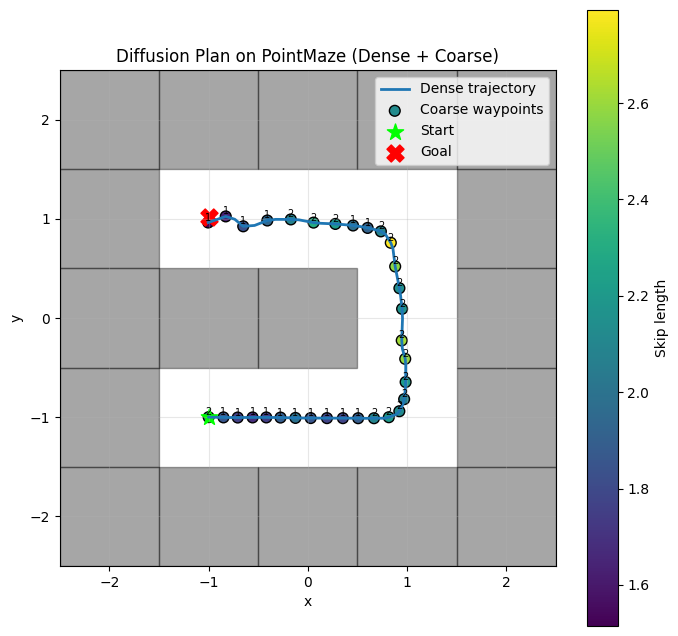

In [128]:
# Create figure
fig, ax = plt.subplots(figsize=(8, 8))

# ===========================================================
# 1) Dense trajectory
# ===========================================================
ax.plot(
    pos_dense[:, 0],
    pos_dense[:, 1],
    linewidth=2,
    color="tab:blue",
    label="Dense trajectory"
)

# ===========================================================
# 2) Coarse waypoints (colored by skip)
# ===========================================================
sc = ax.scatter(
    coarse_pos[:, 0],
    coarse_pos[:, 1],
    c=coarse_skip,
    s=60,
    cmap="viridis",
    edgecolors="k",
    label="Coarse waypoints"
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Skip length")

# Annotate skip values
for i, (x, y) in enumerate(coarse_pos):
    ax.text(x, y, f"{int(coarse_skip[i])}", fontsize=7, ha="center", va="bottom")

# ===========================================================
# 3) Start and Goal
# ===========================================================
ax.scatter(current[0], current[1], s=150, marker="*", color="lime",  label="Start")
ax.scatter(goal[0],    goal[1],    s=150, marker="X", color="red",   label="Goal")

# ===========================================================
# 4) Render MuJoCo maze walls
# ===========================================================
for geom_id in range(mj_model.ngeom):

    name = mujoco.mj_id2name(mj_model, mujoco.mjtObj.mjOBJ_GEOM, geom_id)

    if name is None or ("block" not in name):
        continue

    pos = mj_model.geom_pos[geom_id]      # (x,y,z) center
    size = mj_model.geom_size[geom_id]    # half sizes (hx,hy,hz)

    cx, cy = pos[:2]
    hx, hy = size[:2]

    rect = Rectangle(
        (cx - hx, cy - hy),
        2 * hx,
        2 * hy,
        color="black",
        alpha=0.35,
        zorder=0
    )
    ax.add_patch(rect)

# ===========================================================
# Final styling
# ===========================================================
ax.set_title("Diffusion Plan on PointMaze (Dense + Coarse)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", "box")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")

# Mazes are usually within [-2.5, 2.5]
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)

plt.show()